<a href="https://colab.research.google.com/github/hiraljoshi93/Machine_Learning/blob/main/Copy_of_RF_SURAT_NOWDF_PC1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SURAT RAINFALL PREDICTION**

In [3]:
# =============================================================================
# STEP 0: Setup — libraries and settings
# =============================================================================
# If you run this in Google Colab and the CSV is not in the folder, uncomment:
# from google.colab import files
# uploaded = files.upload()

import warnings
warnings.filterwarnings("ignore")  # hide minor warnings so output is easier to read

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: popular machine-learning library in Python
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

sns.set_theme(style="whitegrid")  # nicer-looking plots

RANDOM_STATE = 42       # fixed seed so results repeat if you run again
CSV_FILENAME = "Surat_9_Para_CSV.csv"
TARGET = "RF"           # column name of rainfall (what we predict)

# Predictor columns we trust for *future* rainfall (meteorology + season)
# We deliberately exclude WDF here — EDA will show why.
MET_FEATURES = ["MTE", "PET", "RCETO"]
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print("Libraries loaded. Ready to start.")

Libraries loaded. Ready to start.


---
## Step 1 — Load the dataset

We read the CSV into a **DataFrame** (a table Python can analyse).  
First look: number of rows, column names, and a few sample rows.

In [4]:
# Read CSV file into a table called df
try:
    df = pd.read_csv(CSV_FILENAME)
    print(f"SUCCESS: Loaded '{CSV_FILENAME}'")
    print(f"  Rows (months): {df.shape[0]}")
    print(f"  Columns: {df.shape[1]}")
except FileNotFoundError:
    raise FileNotFoundError(
        f"File '{CSV_FILENAME}' not found. "
        "Upload it in Colab (uncomment upload lines in Step 0) or place it next to this notebook."
    )

# Show first 5 rows — quick sanity check (years, months, numbers look reasonable?)
display(df.head())

SUCCESS: Loaded 'Surat_9_Para_CSV.csv'
  Rows (months): 1224
  Columns: 11


,Year,Month,RF,ATE,CC,DTR,MTE,PET,RCETO,VP,WDF
0,1901,Jan,2.714,16.204,9.306,12.436,22.459,4.66,2.88,10.343,0.5237
1,1901,Feb,0.000,16.706,9.101,12.660,23.035,5.14,3.41,10.290,0.0000
2,1901,Mar,2.115,21.064,14.990,12.037,27.081,5.82,4.43,12.906,0.3737
3,1901,Apr,0.776,23.017,15.459,10.836,28.427,6.26,4.93,16.422,0.5643
4,1901,May,1.595,24.436,18.931,9.145,29.040,6.14,4.99,19.689,0.5395


---
## Step 2 — Exploratory Data Analysis (EDA)

EDA means *exploring* the data before modelling. We check quality, patterns, and relationships — like inspecting data in Excel before making charts for a report.

### 2.1 Missing values and data types

In [5]:
# Data type of each column (number vs text)
print("Data types:")
print(df.dtypes)

print("\nMissing values per column (0 = good):")
missing = df.isna().sum()
print(missing)

print(f"\nTime span: {df['Year'].min()} to {df['Year'].max()} "
      f"({df['Year'].nunique()} years, {len(df)} monthly records)")

Data types:
Year       int64
Month     object
RF       float64
ATE      float64
CC       float64
DTR      float64
MTE      float64
PET      float64
RCETO    float64
VP       float64
WDF      float64
dtype: object

Missing values per column (0 = good):
Year     0
Month    0
RF       0
ATE      0
CC       0
DTR      0
MTE      0
PET      0
RCETO    0
VP       0
WDF      0
dtype: int64

Time span: 1901 to 2002 (102 years, 1224 monthly records)


### 2.2 Summary statistics for rainfall (RF)

In [6]:
# describe() gives count, mean, std, min, quartiles, max
print("=== Rainfall (RF) summary ===")
display(df[TARGET].describe().to_frame("RF (mm)"))

print("\n=== All numeric columns (short view) ===")
display(df.describe().T.round(2))

=== Rainfall (RF) summary ===


,RF (mm)
count,1224.000000
mean,93.973687
std,159.214278
min,0.000000
25%,0.021000
50%,2.131500
75%,144.616000
max,968.976000



=== All numeric columns (short view) ===


,count,mean,std,min,25%,50%,75%,max
Year,1224.0,1951.50,29.46,1901.00,1926.00,1951.50,1977.00,2002.00
RF,1224.0,93.97,159.21,0.00,0.02,2.13,144.62,968.98
ATE,1224.0,20.83,2.25,15.43,18.90,21.17,22.40,25.41
CC,1224.0,25.32,18.34,1.64,10.73,16.23,41.18,67.48
DTR,1224.0,9.46,2.80,4.63,6.77,10.34,12.03,12.93
MTE,1224.0,25.58,1.93,21.68,23.94,25.05,27.09,29.99
PET,1224.0,5.04,0.74,3.67,4.50,5.02,5.52,6.39
RCETO,1224.0,3.76,0.70,2.71,3.24,3.52,4.32,5.11
VP,1224.0,16.58,4.97,9.70,11.88,14.92,22.11,25.42
WDF,1224.0,3.39,4.77,0.00,0.02,0.65,6.38,19.54


### 2.3 Visual EDA — time trend and seasonal pattern

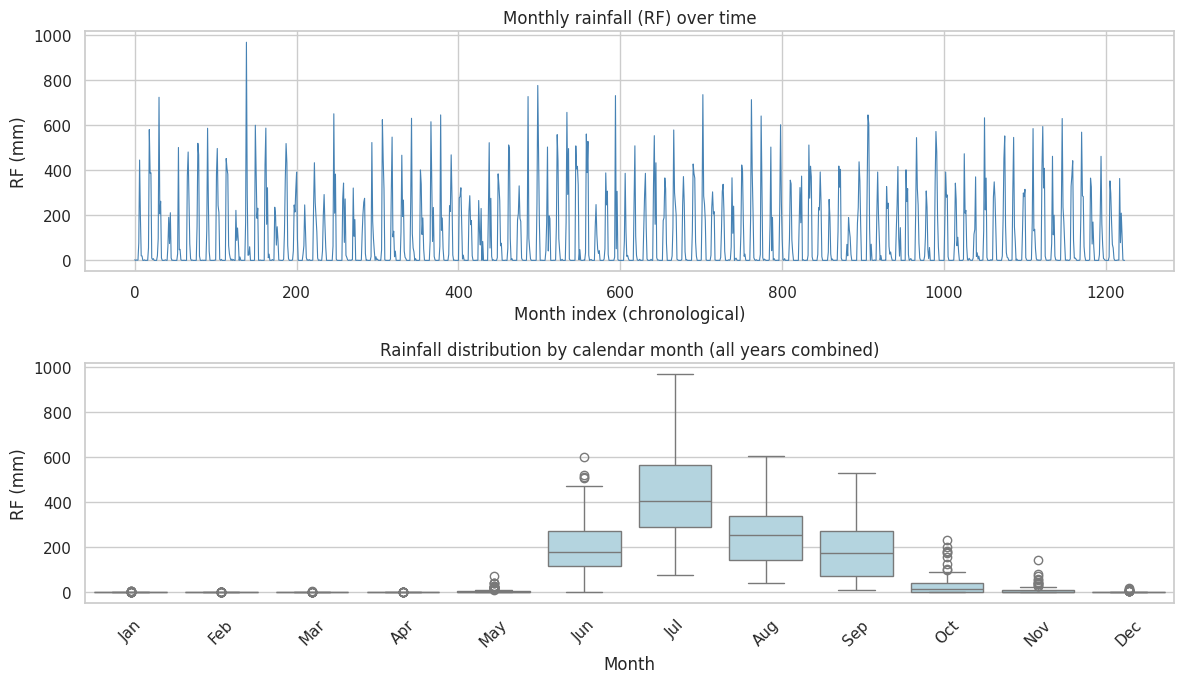

In [7]:
# Build a simple date order for plotting
df_eda = df.copy()
df_eda["month_num"] = df_eda["Month"].map({m: i + 1 for i, m in enumerate(MONTH_ORDER)})
df_eda = df_eda.sort_values(["Year", "month_num"]).reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Plot 1: RF over entire period (line chart)
axes[0].plot(df_eda.index, df_eda[TARGET], linewidth=0.8, color="steelblue")
axes[0].set_title("Monthly rainfall (RF) over time")
axes[0].set_xlabel("Month index (chronological)")
axes[0].set_ylabel("RF (mm)")

# Plot 2: Boxplot by calendar month — shows typical monsoon season
sns.boxplot(data=df_eda, x="Month", y=TARGET, order=MONTH_ORDER, ax=axes[1], color="lightblue")
axes[1].set_title("Rainfall distribution by calendar month (all years combined)")
axes[1].set_ylabel("RF (mm)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 2.4 Correlation — which variables move with rainfall?

Correlation of each column with RF (sorted):


,Correlation with RF
WDF,0.940078
CC,0.815328
VP,0.686037
ATE,0.212285
month_num,0.169345
Year,0.006717
RCETO,-0.163537
MTE,-0.310173
PET,-0.546101
DTR,-0.767327


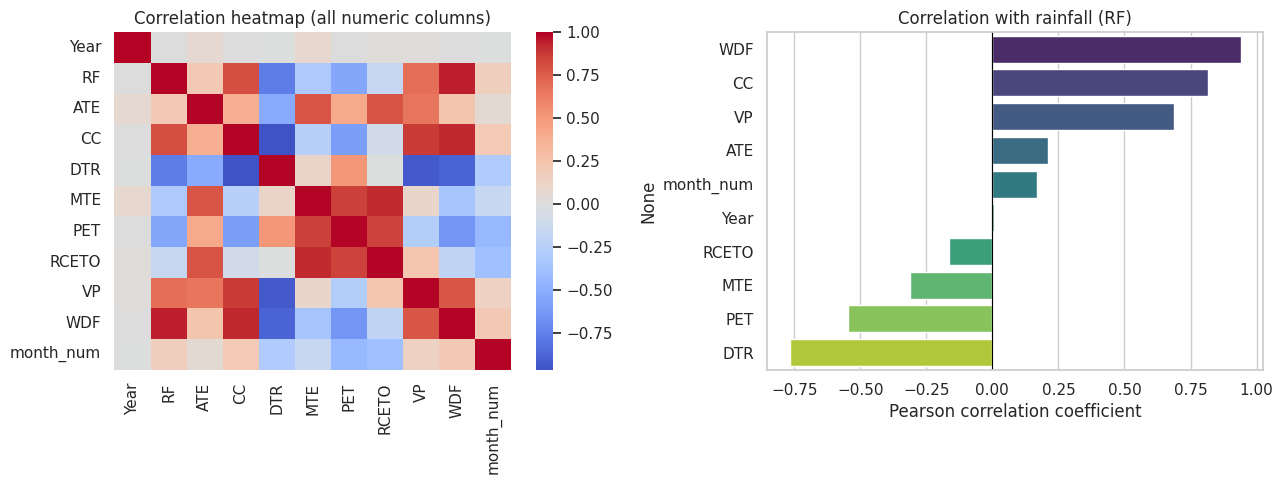


Note: correlation(RF, WDF) = 0.940
WDF is extremely similar to RF. Using WDF to predict RF would be like
using 'yesterday rainfall' to predict 'today rainfall' — accuracy looks
artificially high but is NOT valid for real future forecasting.


In [8]:
# Pearson correlation: +1 = increase together, -1 = one up other down, 0 = weak linear link
numeric_df = df_eda.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
corr_rf = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)

print("Correlation of each column with RF (sorted):")
display(corr_rf.to_frame("Correlation with RF"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Correlation heatmap (all numeric columns)")

sns.barplot(x=corr_rf.values, y=corr_rf.index, ax=axes[1], palette="viridis")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation with rainfall (RF)")
axes[1].set_xlabel("Pearson correlation coefficient")
plt.tight_layout()
plt.show()

# Important teaching point: WDF is almost a copy of RF — not used in main model
wdf_corr = corr_rf.get("WDF", np.nan)
print(f"\nNote: correlation(RF, WDF) = {wdf_corr:.3f}")
if wdf_corr > 0.9:
    print("WDF is extremely similar to RF. Using WDF to predict RF would be like")
    print("using 'yesterday rainfall' to predict 'today rainfall' — accuracy looks")
    print("artificially high but is NOT valid for real future forecasting.")

---
## Step 4 — Feature engineering

**Feature engineering** = creating helpful input columns for the model.

| New feature | Meaning |
|-------------|--------|
| `month_num` | Month as number 1–12 (model learns seasonality) |
| `RF_lag1` | Previous month's rainfall (persistence) |
| `RF_lag12` | Same month last year (annual cycle) |

In [11]:
df = df_eda.copy()  # continue from sorted EDA table

# --- Seasonality feature ---
# Already created month_num in EDA; ensures Jan=1 ... Dec=12

# --- Lag features (only make sense on time-ordered data) ---
USE_LAG_FEATURES = True  # set False if you only want weather variables

df["RF_lag1"] = df[TARGET].shift(1)    # rainfall from previous month
df["RF_lag12"] = df[TARGET].shift(12)  # rainfall from same month, previous year

# Final list of columns fed to the model
BASE_FEATURES = MET_FEATURES + ["month_num"]
LAG_FEATURES = ["RF_lag1", "RF_lag12"]
FEATURES = BASE_FEATURES + (LAG_FEATURES if USE_LAG_FEATURES else [])

# Drop first 12 months: lags are missing (NaN) there
model_df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

print("Features used for modelling:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i}. {f}")
print(f"\nRows available for modelling: {len(model_df)} (lost {len(df) - len(model_df)} rows due to lags)")
display(model_df[["Year", "Month", TARGET] + FEATURES].head(8))

Features used for modelling:
  1. MTE
  2. PET
  3. RCETO
  4. month_num
  5. RF_lag1
  6. RF_lag12

Rows available for modelling: 1212 (lost 12 rows due to lags)


,Year,Month,RF,MTE,PET,RCETO,month_num,RF_lag1,RF_lag12
0,1902,Jan,2.275,24.109,4.73,3.03,1,0.000,2.714
1,1902,Feb,0.000,24.824,5.26,3.61,2,2.275,0.000
2,1902,Mar,0.000,27.860,5.87,4.53,3,0.000,2.115
3,1902,Apr,0.029,29.011,6.31,5.01,4,0.000,0.776
4,1902,May,0.411,29.259,6.18,5.02,5,0.029,1.595
5,1902,Jun,55.080,27.466,5.21,4.33,6,0.411,77.731
6,1902,Jul,581.097,25.025,4.17,3.56,7,55.080,445.800
7,1902,Aug,387.121,24.429,3.91,3.31,8,581.097,194.179


---
## Step 5 — Train / test split



In [12]:
TEST_FRACTION = 0.20  # 20% newest months go to test set
split_idx = int(len(model_df) * (1 - TEST_FRACTION))

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print("TRAIN period:", train_df["Year"].min(), "–", train_df["Year"].max(),
      f"({len(train_df)} months)")
print("TEST period: ", test_df["Year"].min(), "–", test_df["Year"].max(),
      f"({len(test_df)} months)")
print("\nTrain RF mean (mm):", round(y_train.mean(), 2))
print("Test RF mean (mm): ", round(y_test.mean(), 2))

TRAIN period: 1902 – 1982 (969 months)
TEST period:  1982 – 2002 (243 months)

Train RF mean (mm): 94.23
Test RF mean (mm):  94.43


---
## Step 6 — Compare 4 popular algorithms & select the best



Training and evaluating each algorithm on the SAME train/test split...

=== MODEL COMPARISON (sorted best → worst by Test RMSE) ===


,Train_R2,Test_R2,Train_RMSE_mm,Test_RMSE_mm,Test_MAE_mm,Rank_by_Test_RMSE
Algorithm,,,,,,
3. Gradient Boosting,0.972,0.747,27.059,77.753,40.557,1
2. Random Forest,0.956,0.746,33.527,77.888,40.167,2
4. Hist Gradient Boosting,0.906,0.715,49.357,82.559,42.402,3
1. Ridge Regression (linear),0.660,0.702,93.687,84.450,51.080,4



✓ SELECTED MODEL: 3. Gradient Boosting
  Reason: lowest Test RMSE on held-out recent months (primary rule).


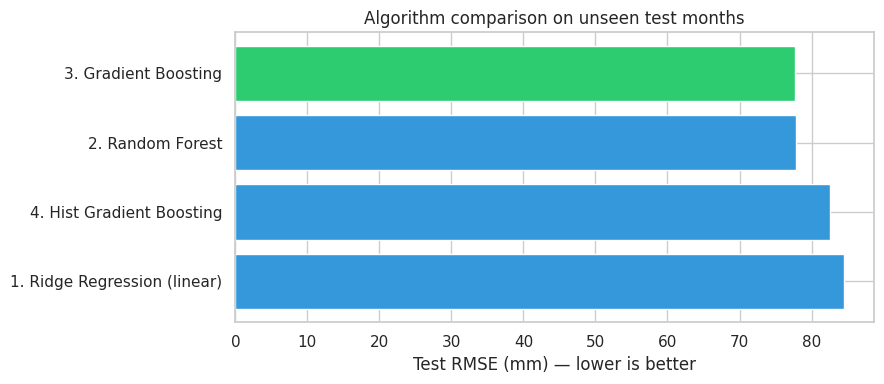

In [13]:
def compute_metrics(y_true, y_pred):
    """Return R2, RMSE, MAE for one model split."""
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


# Dictionary of 4 algorithms (default settings — fair first comparison)
candidate_models = {
    "1. Ridge Regression (linear)": Pipeline([
        ("scaler", StandardScaler()),  # Ridge needs similar scales for all columns
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]),
    "2. Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "3. Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE
    ),
    "4. Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=6, random_state=RANDOM_STATE
    ),
}

comparison_rows = []
fitted_models = {}  # store trained models for optional plots

print("Training and evaluating each algorithm on the SAME train/test split...\n")
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    train_m = compute_metrics(y_train, pred_train)
    test_m = compute_metrics(y_test, pred_test)
    fitted_models[name] = model
    comparison_rows.append({
        "Algorithm": name,
        "Train_R2": train_m["R2"],
        "Test_R2": test_m["R2"],
        "Train_RMSE_mm": train_m["RMSE"],
        "Test_RMSE_mm": test_m["RMSE"],
        "Test_MAE_mm": test_m["MAE"],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Algorithm")
comparison_df = comparison_df.sort_values("Test_RMSE_mm")  # best = top row
comparison_df["Rank_by_Test_RMSE"] = range(1, len(comparison_df) + 1)

print("=== MODEL COMPARISON (sorted best → worst by Test RMSE) ===")
display(comparison_df.round(3))

# --- Select winner ---
SELECTED_MODEL_NAME = comparison_df.index[0]
selected_baseline = fitted_models[SELECTED_MODEL_NAME]
print(f"\n✓ SELECTED MODEL: {SELECTED_MODEL_NAME}")
print("  Reason: lowest Test RMSE on held-out recent months (primary rule).")

# Bar chart: compare Test RMSE across algorithms
plt.figure(figsize=(9, 4))
plot_order = comparison_df.sort_values("Test_RMSE_mm", ascending=True)
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(plot_order))]
plt.barh(plot_order.index, plot_order["Test_RMSE_mm"], color=colors)
plt.xlabel("Test RMSE (mm) — lower is better")
plt.title("Algorithm comparison on unseen test months")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## Step 7 — Add an LSTM Model

Let's also include a Long Short-Term Memory (LSTM) neural network, which is well-suited for time series data. We'll use TensorFlow and Keras to build and train the LSTM model.

Training LSTM model...
LSTM model training complete.

=== UPDATED MODEL COMPARISON (sorted best → worst by Test RMSE) ===


,Train_R2,Test_R2,Train_RMSE_mm,Test_RMSE_mm,Test_MAE_mm,Rank_by_Test_RMSE
Algorithm,,,,,,
3. Gradient Boosting,0.972,0.747,27.059,77.753,40.557,1
2. Random Forest,0.956,0.746,33.527,77.888,40.167,2
4. Hist Gradient Boosting,0.906,0.715,49.357,82.559,42.402,3
1. Ridge Regression (linear),0.660,0.702,93.687,84.450,51.080,4
5. LSTM,0.598,0.619,101.834,95.497,52.395,5



✓ NEW SELECTED MODEL: 3. Gradient Boosting
  Reason: lowest Test RMSE on held-out recent months (primary rule).


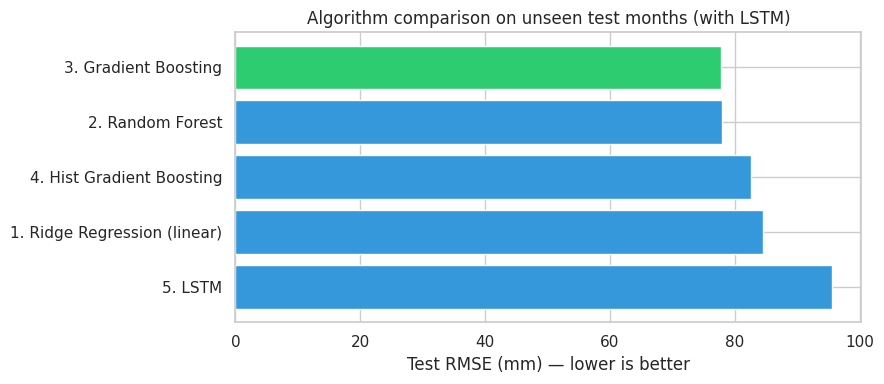

In [14]:
def compute_metrics(y_true, y_pred):
    """Return R2, RMSE, MAE for one model split."""
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

# Import TensorFlow and Keras for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Check if comparison_rows and fitted_models are defined. If not, re-initialize them.
# This is crucial if the kernel state was reset or cells were run out of order.
if 'comparison_rows' not in globals():
    if 'comparison_df' in globals():
        comparison_rows = comparison_df.reset_index().to_dict(orient='records')
        print("Reconstructed 'comparison_rows' from 'comparison_df'.")
    else:
        comparison_rows = []
        print("Initialized 'comparison_rows' as empty. Please ensure the 'Compare 4 popular algorithms' cell was run.")

if 'fitted_models' not in globals():
    fitted_models = {}
    print("Initialized 'fitted_models' as empty. Actual fitted model objects from previous runs are not available.")
    print("If you need `selected_baseline` to be an actual fitted model, please re-run the 'Compare 4 popular algorithms' cell.")

# Reshape input data for LSTM: (samples, timesteps, features)
# For this implementation, we'll treat each month's data as a single timestep.
X_train_lstm = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

# Define the LSTM model architecture
def create_lstm_model(n_features, units=50, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, activation='relu', input_shape=(1, n_features)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model

# Create and train the LSTM model
print("Training LSTM model...")
n_features = X_train.shape[1]
lstm_model = create_lstm_model(n_features, units=50, dropout_rate=0.2, learning_rate=0.001)
history = lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=32, verbose=0, validation_split=0.1)
print("LSTM model training complete.")

# Make predictions with the LSTM model
pred_train_lstm = lstm_model.predict(X_train_lstm, verbose=0).flatten()
pred_test_lstm = lstm_model.predict(X_test_lstm, verbose=0).flatten()

# Compute metrics for LSTM
train_m_lstm = compute_metrics(y_train, pred_train_lstm)
test_m_lstm = compute_metrics(y_test, pred_test_lstm)

# Append LSTM results to comparison_rows
comparison_rows.append({
    "Algorithm": "5. LSTM",
    "Train_R2": train_m_lstm["R2"],
    "Test_R2": test_m_lstm["R2"],
    "Train_RMSE_mm": train_m_lstm["RMSE"],
    "Test_RMSE_mm": test_m_lstm["RMSE"],
    "Test_MAE_mm": test_m_lstm["MAE"],
})

# Recreate and display the updated comparison DataFrame
comparison_df = pd.DataFrame(comparison_rows).set_index("Algorithm")
comparison_df = comparison_df.sort_values("Test_RMSE_mm") # best = top row
comparison_df["Rank_by_Test_RMSE"] = range(1, len(comparison_df) + 1)

print("\n=== UPDATED MODEL COMPARISON (sorted best → worst by Test RMSE) ===")
display(comparison_df.round(3))

# --- Select winner (with LSTM included) ---
SELECTED_MODEL_NAME = comparison_df.index[0]
print(f"\n✓ NEW SELECTED MODEL: {SELECTED_MODEL_NAME}")
print("  Reason: lowest Test RMSE on held-out recent months (primary rule).")

# Bar chart: compare Test RMSE across algorithms (updated)
plt.figure(figsize=(9, 4))
plot_order = comparison_df.sort_values("Test_RMSE_mm", ascending=True)
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(plot_order))]
plt.barh(plot_order.index, plot_order["Test_RMSE_mm"], color=colors)
plt.xlabel("Test RMSE (mm) — lower is better")
plt.title("Algorithm comparison on unseen test months (with LSTM)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## Step 8 — Select Top 2 Models

Based on the `Test_RMSE_mm`, let's explicitly select the top 2 performing models for further consideration.

In [15]:
# Select the top 2 models based on Test_RMSE_mm
top_2_models_df = comparison_df.sort_values("Test_RMSE_mm").head(2)

# Display the top 2 models
print("=== Top 2 Models by Test RMSE ===")
display(top_2_models_df.round(3))

# Assign the best model (still Ridge Regression based on current results)
SELECTED_MODEL_NAME_BEST = top_2_models_df.index[0]
print(f"\n✓ Best Model: {SELECTED_MODEL_NAME_BEST}")

# Assign the second best model
SELECTED_MODEL_NAME_SECOND_BEST = top_2_models_df.index[1]
print(f"✓ Second Best Model: {SELECTED_MODEL_NAME_SECOND_BEST}")

# For future steps, you can retrieve the actual fitted models if needed:
# best_model = fitted_models.get(SELECTED_MODEL_NAME_BEST)
# second_best_model = fitted_models.get(SELECTED_MODEL_NAME_SECOND_BEST)
# Note: If 'fitted_models' was re-initialized as empty, these will be None unless
# the 'Compare 4 popular algorithms' cell was re-run just before this.

=== Top 2 Models by Test RMSE ===


,Train_R2,Test_R2,Train_RMSE_mm,Test_RMSE_mm,Test_MAE_mm,Rank_by_Test_RMSE
Algorithm,,,,,,
3. Gradient Boosting,0.972,0.747,27.059,77.753,40.557,1
2. Random Forest,0.956,0.746,33.527,77.888,40.167,2



✓ Best Model: 3. Gradient Boosting
✓ Second Best Model: 2. Random Forest


In [16]:
# Overfitting gap: Train R2 minus Test R2 (large gap = memorizing training years)
comparison_df["Overfit_gap_R2"] = comparison_df["Train_R2"] - comparison_df["Test_R2"]
print("Overfitting check (Train R² − Test R²; smaller gap is safer):")
display(comparison_df[["Train_R2", "Test_R2", "Overfit_gap_R2"]].round(3))

Overfitting check (Train R² − Test R²; smaller gap is safer):


,Train_R2,Test_R2,Overfit_gap_R2
Algorithm,,,
3. Gradient Boosting,0.972,0.747,0.224
2. Random Forest,0.956,0.746,0.210
4. Hist Gradient Boosting,0.906,0.715,0.190
1. Ridge Regression (linear),0.660,0.702,-0.042
5. LSTM,0.598,0.619,-0.021


---
## Step 7 — Hyperparameter tuning


In [17]:
param_grids = {
    "1. Ridge Regression (linear)": {"model__alpha": [0.1, 1.0, 10.0, 100.0]},
    "2. Random Forest": {
        "n_estimators": [200, 300],
        "max_depth": [10, 20, None],
        "min_samples_leaf": [1, 3],
    },
    "3. Gradient Boosting": {
        "n_estimators": [150, 250],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [3, 5],
    },
    "4. Hist Gradient Boosting": {
        "max_iter": [200, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [4, 6, 8],
    },
}

tscv = TimeSeriesSplit(n_splits=3)
tuning_estimator = clone(candidate_models[SELECTED_MODEL_NAME])

print(f"Tuning: {SELECTED_MODEL_NAME} (may take 1–4 minutes)...")
grid_search = GridSearchCV(
    estimator=tuning_estimator,
    param_grid=param_grids[SELECTED_MODEL_NAME],
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("\n=== BEST HYPERPARAMETERS ===")
for key, val in grid_search.best_params_.items():
    print(f"  {key}: {val}")
print(f"\nCross-validation RMSE: {-grid_search.best_score_:.2f} mm")

Tuning: 3. Gradient Boosting (may take 1–4 minutes)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

=== BEST HYPERPARAMETERS ===
  learning_rate: 0.03
  max_depth: 3
  n_estimators: 150

Cross-validation RMSE: 91.06 mm


In [18]:
cv_results = pd.DataFrame(grid_search.cv_results_)
param_cols = [c for c in cv_results.columns if c.startswith("param_")]
top5 = cv_results.nsmallest(5, "rank_test_score")[param_cols + ["mean_test_score", "rank_test_score"]].copy()
top5["CV_RMSE_mm"] = (-top5["mean_test_score"]).round(2)
top5 = top5.drop(columns=["mean_test_score"])
print(f"Top 5 settings for {SELECTED_MODEL_NAME}:")
display(top5)

Top 5 settings for 3. Gradient Boosting:


,param_learning_rate,param_max_depth,param_n_estimators,rank_test_score,CV_RMSE_mm
0,0.03,3,150,1,91.06
4,0.05,3,150,2,93.62
1,0.03,3,250,3,93.92
2,0.03,5,150,4,96.01
5,0.05,3,250,5,96.06


---
## Step 8 — Final model evaluation (selected + tuned)

We use the **tuned winner** from Steps 6–7 on train and test months.

In [19]:
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)
print(f"Final model: {SELECTED_MODEL_NAME} (after hyperparameter tuning)")

# Predictions on train and test
y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)


def show_metrics(split_name, y_true, y_pred):
    """Print regression metrics with short explanations."""
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n--- {split_name} set ---")
    print(f"  R²   = {r2:.3f}  → fraction of rainfall variability explained (1.0 = perfect)")
    print(f"  RMSE = {rmse:.2f} mm → typical prediction error (penalizes large errors)")
    print(f"  MAE  = {mae:.2f} mm → average absolute error (easier to explain in reports)")
    return {"R2": r2, "RMSE": rmse, "MAE": mae}


train_metrics = show_metrics("TRAIN", y_train, y_pred_train)
test_metrics = show_metrics("TEST (unseen)", y_test, y_pred_test)

metrics_table = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
display(metrics_table.round(3))

# Compare tuned model vs same algorithm before tuning (Step 6 defaults)
baseline_pred = fitted_models[SELECTED_MODEL_NAME].predict(X_test)
baseline_rmse = float(np.sqrt(mean_squared_error(y_test, baseline_pred)))
tuned_rmse = test_metrics["RMSE"]
print(f"\n{SELECTED_MODEL_NAME} — Test RMSE before tuning: {baseline_rmse:.2f} mm")
print(f"{SELECTED_MODEL_NAME} — Test RMSE after tuning:  {tuned_rmse:.2f} mm")
if tuned_rmse < baseline_rmse:
    print("→ Tuning improved the model on the test period.")
else:
    print("→ Tuning did not beat defaults on test; defaults were already strong (report both).")

Final model: 3. Gradient Boosting (after hyperparameter tuning)

--- TRAIN set ---
  R²   = 0.810  → fraction of rainfall variability explained (1.0 = perfect)
  RMSE = 69.95 mm → typical prediction error (penalizes large errors)
  MAE  = 38.89 mm → average absolute error (easier to explain in reports)

--- TEST (unseen) set ---
  R²   = 0.762  → fraction of rainfall variability explained (1.0 = perfect)
  RMSE = 75.53 mm → typical prediction error (penalizes large errors)
  MAE  = 40.30 mm → average absolute error (easier to explain in reports)


,R2,RMSE,MAE
Train,0.810,69.948,38.886
Test,0.762,75.526,40.297



3. Gradient Boosting — Test RMSE before tuning: 77.75 mm
3. Gradient Boosting — Test RMSE after tuning:  75.53 mm
→ Tuning improved the model on the test period.


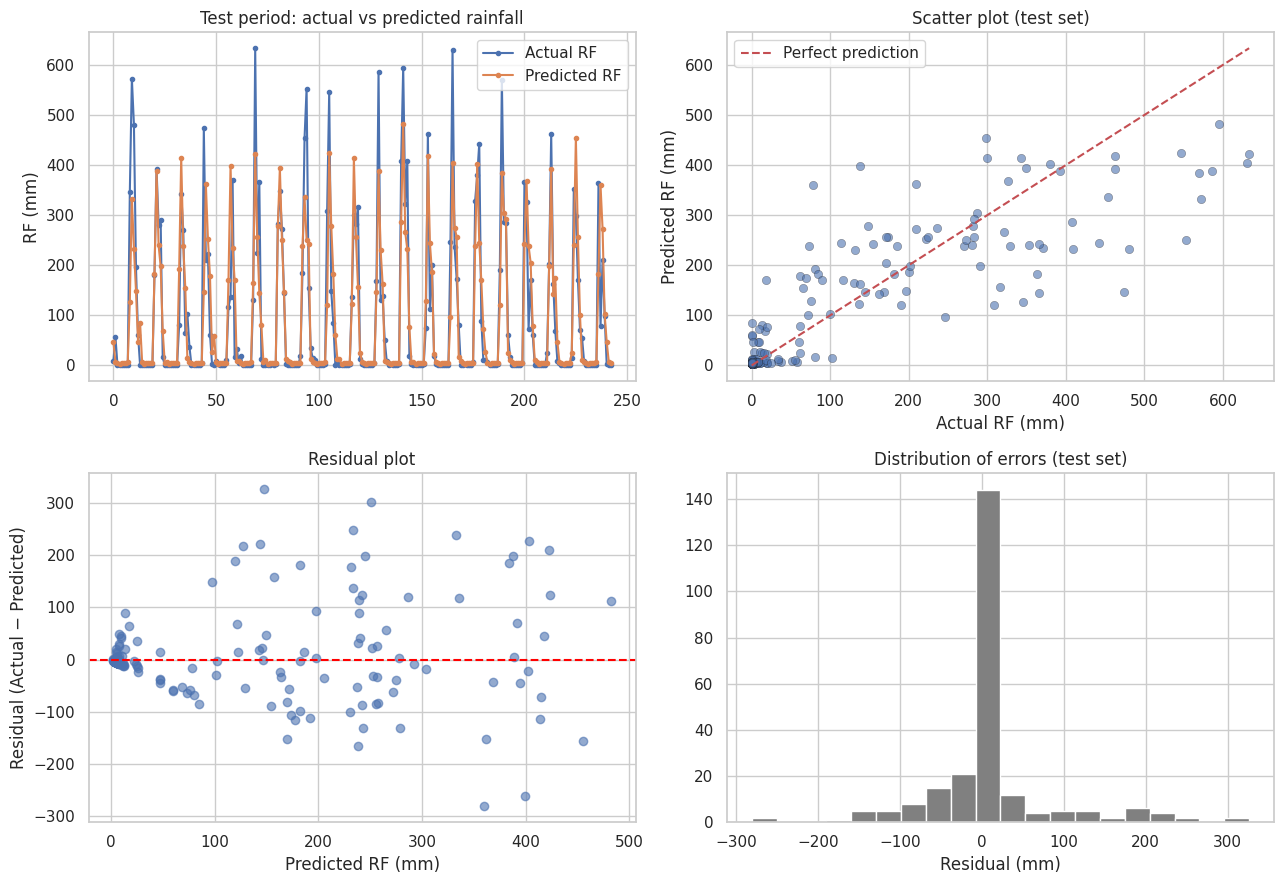

In [20]:
# --- Visual evaluation ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) Actual vs predicted over test months
axes[0, 0].plot(y_test.values, label="Actual RF", marker="o", markersize=3)
axes[0, 0].plot(y_pred_test, label="Predicted RF", marker=".")
axes[0, 0].set_title("Test period: actual vs predicted rainfall")
axes[0, 0].set_ylabel("RF (mm)")
axes[0, 0].legend()

# 2) Scatter: points on red line = perfect prediction
axes[0, 1].scatter(y_test, y_pred_test, alpha=0.6, edgecolors="k", linewidths=0.3)
mx = max(y_test.max(), y_pred_test.max())
axes[0, 1].plot([0, mx], [0, mx], "r--", label="Perfect prediction")
axes[0, 1].set_xlabel("Actual RF (mm)")
axes[0, 1].set_ylabel("Predicted RF (mm)")
axes[0, 1].set_title("Scatter plot (test set)")
axes[0, 1].legend()

# 3) Residuals = actual - predicted (should scatter around 0)
residuals = y_test.values - y_pred_test
axes[1, 0].scatter(y_pred_test, residuals, alpha=0.6)
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_xlabel("Predicted RF (mm)")
axes[1, 0].set_ylabel("Residual (Actual − Predicted)")
axes[1, 0].set_title("Residual plot")

# 4) Error distribution
axes[1, 1].hist(residuals, bins=20, color="gray", edgecolor="white")
axes[1, 1].set_xlabel("Residual (mm)")
axes[1, 1].set_title("Distribution of errors (test set)")

plt.tight_layout()
plt.show()

---
## Step 9 — Mathematical formula (top 3–4 dominant predictors)



In [21]:
N_TOP_FEATURES = 10  # change to 3 if you want only three predictors in the formula


def rank_predictor_importance(model, X, y, feature_names):
    """
    Rank input columns by how much they drive predictions.
    Works for tree models, Ridge pipeline, etc.
    """
    # Tree-based models: built-in importance
    if hasattr(model, "feature_importances_"):
        scores = pd.Series(model.feature_importances_, index=feature_names)
        method = "feature_importances_ from winning model"
        return scores.sort_values(ascending=False), method

    # Ridge inside Pipeline (scaled inputs)
    if hasattr(model, "named_steps") and "model" in model.named_steps:
        coefs = np.abs(model.named_steps["model"].coef_)
        scores = pd.Series(coefs, index=feature_names)
        method = "absolute Ridge coefficients (after scaling in pipeline)"
        return scores.sort_values(ascending=False), method

    # Fallback: permutation importance (model-agnostic)
    perm = permutation_importance(
        model, X, y, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    scores = pd.Series(perm.importances_mean, index=feature_names)
    method = "permutation importance on training data"
    return scores.sort_values(ascending=False), method


importance_scores, importance_method = rank_predictor_importance(
    final_model, X_train, y_train, FEATURES
)

print(f"How importance was measured: {importance_method}")
print("\nAll predictors ranked (highest first):")
display(importance_scores.to_frame("importance").round(4))

top_features = importance_scores.head(N_TOP_FEATURES).index.tolist()
print(f"\nTop {N_TOP_FEATURES} columns used in the formula:", top_features)

How importance was measured: feature_importances_ from winning model

All predictors ranked (highest first):


,importance
RF_lag12,0.5398
PET,0.3271
MTE,0.0514
month_num,0.0401
RCETO,0.0249
RF_lag1,0.0167



Top 10 columns used in the formula: ['RF_lag12', 'PET', 'MTE', 'month_num', 'RCETO', 'RF_lag1']


In [22]:
# Fit a simple linear model: RF = intercept + sum(coef_i * column_i)
# Trained on TRAIN data only, using raw column values (no scaling → direct formula)
formula_model = LinearRegression()
formula_model.fit(X_train[top_features], y_train)

intercept = formula_model.intercept_
coefficients = pd.Series(formula_model.coef_, index=top_features)

# --- Plain-English / report formula ---
def build_formula_string(target, coef_series, b0):
    parts = [f"{b0:.4f}"]
    for name, coef in coef_series.items():
        sign = "+" if coef >= 0 else "-"
        parts.append(f" {sign} {abs(coef):.4f}×{name}")
    return f"{target} = " + "".join(parts)


formula_plain = build_formula_string(TARGET, coefficients, intercept)
print("=" * 70)
print("RAINFALL FORMULA (linear, top predictors only)")
print("=" * 70)
print(formula_plain)
print("\nCopy the line above into your report / thesis.")

# --- LaTeX version for Word / LaTeX reports ---
latex_terms = [f"{intercept:.4f}"]
for name, coef in coefficients.items():
    sign = "+" if coef >= 0 else "-"
    safe_name = name.replace("_", "\\_")
    latex_terms.append(f" {sign} {abs(coef):.4f}\\cdot \\mathrm{{{safe_name}}}")
formula_latex = "RF = " + "".join(latex_terms)
print("\nLaTeX form:")
print(formula_latex)

# Coefficient table with meaning
coef_table = pd.DataFrame({
    "Variable": top_features,
    "Coefficient (β)": coefficients.values,
    "Meaning": [
        f"If {f} increases by 1 unit, RF changes by {coefficients[f]:+.3f} mm (others fixed)"
        for f in top_features
    ],
})
coef_table.loc[len(coef_table)] = {
    "Variable": "Intercept (β₀)",
    "Coefficient (β)": intercept,
    "Meaning": "Predicted RF when all top predictors are zero (reference baseline)",
}
display(coef_table)

RAINFALL FORMULA (linear, top predictors only)
RF = 1175.8115 + 0.2140×RF_lag12 - 245.5014×PET - 37.4632×MTE + 4.3090×month_num + 286.3734×RCETO - 0.1207×RF_lag1

Copy the line above into your report / thesis.

LaTeX form:
RF = 1175.8115 + 0.2140\cdot \mathrm{RF\_lag12} - 245.5014\cdot \mathrm{PET} - 37.4632\cdot \mathrm{MTE} + 4.3090\cdot \mathrm{month\_num} + 286.3734\cdot \mathrm{RCETO} - 0.1207\cdot \mathrm{RF\_lag1}


,Variable,Coefficient (β),Meaning
0,RF_lag12,0.214021,"If RF_lag12 increases by 1 unit, RF changes by..."
1,PET,-245.501416,"If PET increases by 1 unit, RF changes by -245..."
2,MTE,-37.463189,"If MTE increases by 1 unit, RF changes by -37...."
3,month_num,4.309008,"If month_num increases by 1 unit, RF changes b..."
4,RCETO,286.373369,"If RCETO increases by 1 unit, RF changes by +2..."
5,RF_lag1,-0.120721,"If RF_lag1 increases by 1 unit, RF changes by ..."
6,Intercept (β₀),1175.811495,Predicted RF when all top predictors are zero ...


In [23]:
# How well does the simple formula match reality?
y_formula_train = formula_model.predict(X_train[top_features])
y_formula_test = formula_model.predict(X_test[top_features])

formula_metrics = pd.DataFrame([
    {
        "Model": f"Linear formula ({N_TOP_FEATURES} vars)",
        "Split": "Train",
        "R2": r2_score(y_train, y_formula_train),
        "RMSE_mm": np.sqrt(mean_squared_error(y_train, y_formula_train)),
    },
    {
        "Model": f"Linear formula ({N_TOP_FEATURES} vars)",
        "Split": "Test",
        "R2": r2_score(y_test, y_formula_test),
        "RMSE_mm": np.sqrt(mean_squared_error(y_test, y_formula_test)),
    },
    {
        "Model": SELECTED_MODEL_NAME,
        "Split": "Test",
        "R2": test_metrics["R2"],
        "RMSE_mm": test_metrics["RMSE"],
    },
])
display(formula_metrics.round(3))

# Worked example: plug in one test month
example = test_df.iloc[0]
manual_calc = intercept + sum(coefficients[f] * example[f] for f in top_features)
predicted = formula_model.predict(example[top_features].to_frame().T)[0]

print(f"\nWorked example — {int(example['Year'])} {example['Month']}:")
for f in top_features:
    print(f"  {f} = {example[f]:.4f}")
print(f"  Manual RF  = {manual_calc:.2f} mm  (using formula)")
print(f"  Python RF  = {predicted:.2f} mm  (same calculation)")
print(f"  Actual RF  = {example[TARGET]:.2f} mm")

,Model,Split,R2,RMSE_mm
0,Linear formula (10 vars),Train,0.660,93.677
1,Linear formula (10 vars),Test,0.702,84.401
2,3. Gradient Boosting,Test,0.762,75.526



Worked example — 1982 Oct:
  RF_lag12 = 76.3580
  PET = 5.1800
  MTE = 27.7930
  month_num = 10.0000
  RCETO = 3.8600
  RF_lag1 = 49.0230
  Manual RF  = 21.82 mm  (using formula)
  Python RF  = 21.82 mm  (same calculation)
  Actual RF  = 8.10 mm


In [24]:
# Full formula summary in notebook output only (no file download)
print("=" * 70)
print("FORMULA SUMMARY (copy from output below for your report)")
print("=" * 70)
print(f"Source model: {SELECTED_MODEL_NAME}")
print(f"Importance method: {importance_method}")
print(f"Top predictors: {', '.join(top_features)}\n")
print("Plain formula:")
print(formula_plain)
print("\nLaTeX:")
print(formula_latex)
print("\nCoefficients:")
display(coef_table)

FORMULA SUMMARY (copy from output below for your report)
Source model: 3. Gradient Boosting
Importance method: feature_importances_ from winning model
Top predictors: RF_lag12, PET, MTE, month_num, RCETO, RF_lag1

Plain formula:
RF = 1175.8115 + 0.2140×RF_lag12 - 245.5014×PET - 37.4632×MTE + 4.3090×month_num + 286.3734×RCETO - 0.1207×RF_lag1

LaTeX:
RF = 1175.8115 + 0.2140\cdot \mathrm{RF\_lag12} - 245.5014\cdot \mathrm{PET} - 37.4632\cdot \mathrm{MTE} + 4.3090\cdot \mathrm{month\_num} + 286.3734\cdot \mathrm{RCETO} - 0.1207\cdot \mathrm{RF\_lag1}

Coefficients:


,Variable,Coefficient (β),Meaning
0,RF_lag12,0.214021,"If RF_lag12 increases by 1 unit, RF changes by..."
1,PET,-245.501416,"If PET increases by 1 unit, RF changes by -245..."
2,MTE,-37.463189,"If MTE increases by 1 unit, RF changes by -37...."
3,month_num,4.309008,"If month_num increases by 1 unit, RF changes b..."
4,RCETO,286.373369,"If RCETO increases by 1 unit, RF changes by +2..."
5,RF_lag1,-0.120721,"If RF_lag1 increases by 1 unit, RF changes by ..."
6,Intercept (β₀),1175.811495,Predicted RF when all top predictors are zero ...
